# XGBoost Classification Exercise

![Namespace Labs](../../../../labs.png)

pip install xgboost

## Churn Prediction

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
# Read in churn.csv
df = pd.read_csv('churn.csv')

In [22]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [23]:
# check the head of the loaded dataframe


<Axes: xlabel='Churn', ylabel='count'>

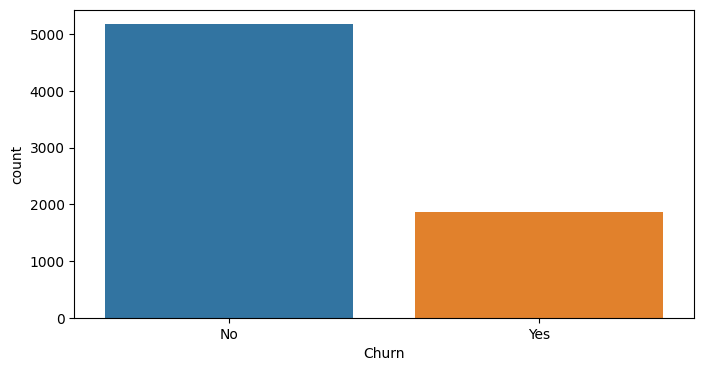

In [24]:
plt.figure(figsize=(8,4))
sns.countplot(data=df, x='Churn', hue='Churn')

In [25]:
# Plot the graph below


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [27]:
# Create a dataframe called cat_feats
# It should contain all the categorical features of the 
# Data Frame
cat_feats = df.select_dtypes(include=['O']).columns[1:-1]
cat_feats

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

In [28]:
# Convert Churn into a dummy variable
dff = pd.get_dummies(data=df, columns=['Churn'], drop_first=True)
dff.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn_Yes
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,False
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,False
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,True
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,False
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,True


In [29]:
from category_encoders import OrdinalEncoder
enc = OrdinalEncoder(cols = cat_feats,  handle_unknown = 'return_nan', handle_missing = 'return_nan')
df_trans = enc.fit_transform(dff)
df_trans.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn_Yes
0,7590-VHVEG,1.0,0,1.0,1.0,1,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,29.85,29.85,False
1,5575-GNVDE,2.0,0,2.0,1.0,34,2.0,2.0,1.0,2.0,...,2.0,1.0,1.0,1.0,2.0,2.0,2.0,56.95,1889.50,False
2,3668-QPYBK,2.0,0,2.0,1.0,2,2.0,2.0,1.0,2.0,...,1.0,1.0,1.0,1.0,1.0,1.0,2.0,53.85,108.15,True
3,7795-CFOCW,2.0,0,2.0,1.0,45,1.0,1.0,1.0,2.0,...,2.0,2.0,1.0,1.0,2.0,2.0,3.0,42.30,1840.75,False
4,9237-HQITU,1.0,0,2.0,1.0,2,2.0,2.0,2.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,70.70,151.65,True


In [30]:
# Convert the categories into integers
# Display the head of the converted dataframe


In [31]:
# Create the X variable
X = df_trans.drop(['customerID', 'Churn_Yes'], axis=1)

In [32]:
# Create the y variable
y = df_trans.Churn_Yes

In [33]:
# Split the data into a training and testing set
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y)

In [34]:
# Import XGBClassifier
from xgboost import XGBClassifier

In [35]:
# Create an instance of LGBMClassifier
model = XGBClassifier()

In [36]:
model.fit(X_train,  y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [37]:
# Fit the data to the training set


In [38]:
# Make predctions
# Store the predictions in a variable
predictions = model.predict(X_test)

In [39]:
# import the common classification metrics
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

In [40]:
# Check the model's accuracy
accuracy_score(y_test, predictions)

0.7881885292447472

In [41]:
confusion_matrix(y_test, predictions)

array([[1152,  146],
       [ 227,  236]])

In [42]:
# Print the confusion Matrix

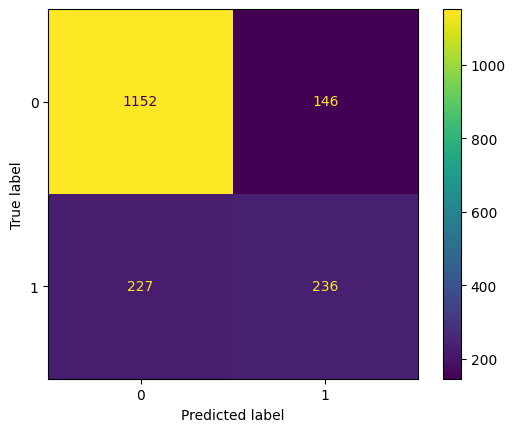

In [43]:
# Plot the confussion matrix
cm = confusion_matrix(y_test, predictions, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=model.classes_)
disp.plot()

In [44]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

       False       0.84      0.89      0.86      1298
        True       0.62      0.51      0.56       463

    accuracy                           0.79      1761
   macro avg       0.73      0.70      0.71      1761
weighted avg       0.78      0.79      0.78      1761



In [45]:
# Print the classification report


Happy Coding!